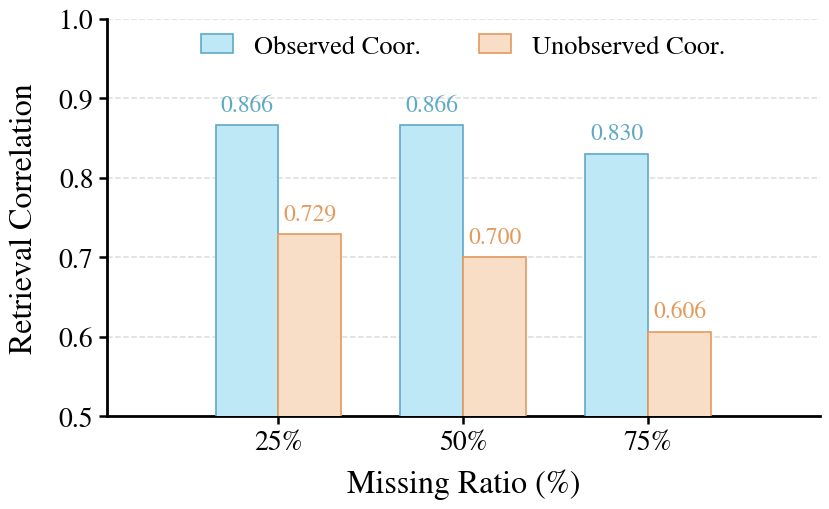

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
missing_ratios = np.array([25, 50, 75])

observed = np.array([0.866, 0.866, 0.830])
unobserved = np.array([0.729, 0.700, 0.606])

# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,
    "axes.labelsize": 23,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 19,
    "axes.linewidth": 2.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


fig, ax = plt.subplots(figsize=(8.6, 5.4))

x = np.arange(len(missing_ratios))
width = 0.34

# Muted colors inspired by the reference bar chart
# observed_color = "#7FA8D6"      # muted medium blue
# unobserved_color = "#93C98D"    # muted soft green

# observed_edge = "#5E82AD"
# unobserved_edge = "#6CA765"


observed_color = "#BFE8F7"      # light cyan-blue
unobserved_color = "#F8DEC7"    # light warm yellow-orange

observed_edge = "#5FA9C4"       # cyan-blue border
unobserved_edge = "#E39A5D"     # orange border

bars_obs = ax.bar(
    x - width / 2,
    observed,
    width=width,
    color=observed_color,
    edgecolor=observed_edge,
    linewidth=1.2,
    label="Observed Coor.",
    zorder=3,
)

bars_unobs = ax.bar(
    x + width / 2,
    unobserved,
    width=width,
    color=unobserved_color,
    edgecolor=unobserved_edge,
    linewidth=1.2,
    label="Unobserved Coor.",
    zorder=3,
)

# =========================
# Axes
# =========================
ax.set_xlabel("Missing Ratio (%)", labelpad=10)
ax.set_ylabel("Retrieval Correlation", labelpad=14)

ax.set_xticks(x)
ax.set_xticklabels([f"{v}%" for v in missing_ratios])

ax.set_ylim(0.5, 1.0)
ax.set_yticks(np.arange(0.5, 1.01, 0.1))

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=1.1,
    color="#D7D7D7",
    alpha=0.85,
    zorder=0,
)

# Reference-style clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2.0)
ax.spines["bottom"].set_linewidth(2.0)

ax.tick_params(axis="both", width=1.8, length=6)

# =========================
# Value labels
# =========================
def add_labels(bars, color):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.012,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=17,
            color=color,
        )

add_labels(bars_obs, observed_edge)
add_labels(bars_unobs, unobserved_edge)

# =========================
# Legend
# =========================
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    handlelength=1.2,
    columnspacing=2.2,
)

ax.margins(x=0.22)

plt.tight_layout(pad=0.9)

plt.savefig("retrieval_correlation_bar.pdf", bbox_inches="tight")

plt.show()


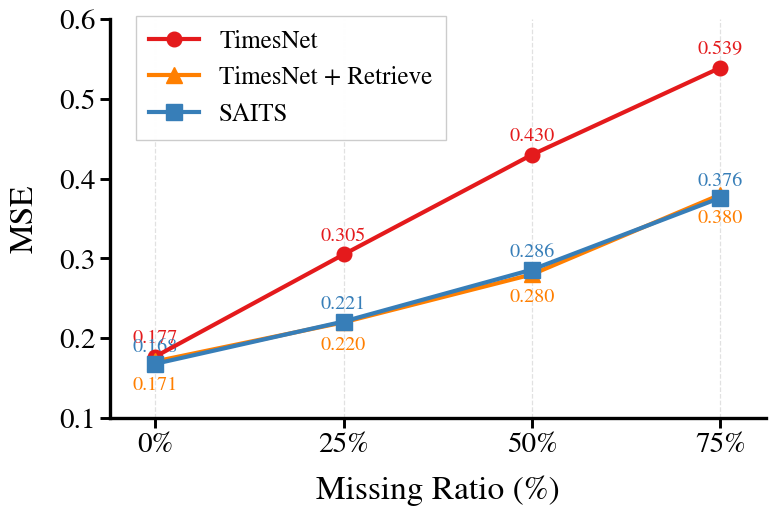

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
missing_ratios = np.array([0, 25, 50, 75])

timesnet = np.array([0.177, 0.305, 0.430, 0.539])
timesnet_retrieval = np.array([0.171, 0.220, 0.280, 0.380])
saits = np.array([0.168, 0.221, 0.286, 0.376])

# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,
    "axes.labelsize": 24,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 18,
    "axes.linewidth": 2.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(8, 5.4))

# Colors inspired by the provided reference
timesnet_color = "#E41A1C"       # red
retrieval_color = "#FF7F00"      # orange
saits_color = "#377EB8"          # blue

# =========================
# Lines
# =========================
ax.plot(
    missing_ratios,
    timesnet,
    marker="o",
    markersize=10.5,
    linewidth=3.0,
    color=timesnet_color,
    markerfacecolor=timesnet_color,
    markeredgecolor=timesnet_color,
    label="TimesNet",
    zorder=4,
)

ax.plot(
    missing_ratios,
    timesnet_retrieval,
    marker="^",
    markersize=11.5,
    linewidth=3.0,
    color=retrieval_color,
    markerfacecolor=retrieval_color,
    markeredgecolor=retrieval_color,
    label="TimesNet + Retrieve",
    zorder=4,
)

ax.plot(
    missing_ratios,
    saits,
    marker="s",
    markersize=11,
    linewidth=3.0,
    color=saits_color,
    markerfacecolor=saits_color,
    markeredgecolor=saits_color,
    label="SAITS",
    zorder=4,
)

# =========================
# Axes
# =========================
ax.set_xlabel("Missing Ratio (%)", labelpad=12)
ax.set_ylabel("MSE", labelpad=14)

ax.set_xticks(missing_ratios)
ax.set_xticklabels([f"{v}%" for v in missing_ratios])

ax.set_ylim(0.1, 0.58)
ax.set_yticks(np.arange(0.1, 0.61, 0.1))

# Subtle y-grid; remove if you want the stronger reference look
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.9,
    color="#D8D8D8",
    alpha=0.75,
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2.4)
ax.spines["bottom"].set_linewidth(2.4)

ax.tick_params(axis="both", width=2.1, length=7, direction="out")

# =========================
# Value labels
# =========================
def add_labels(xs, ys, color, dy):
    for x, y in zip(xs, ys):
        ax.text(
            x,
            y + dy,
            f"{y:.3f}",
            ha="center",
            va="bottom" if dy >= 0 else "top",
            fontsize=14.5,
            color=color,
        )

add_labels(missing_ratios, timesnet, timesnet_color, 0.013)
add_labels(missing_ratios, timesnet_retrieval, retrieval_color, -0.018)
add_labels(missing_ratios, saits, saits_color, 0.011)

# =========================
# Legend inside
# =========================
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.02, 1.04),
    frameon=True,
    fancybox=False,
    framealpha=0.99,
    edgecolor="#CCCCCC",
    facecolor="white",
    borderpad=0.55,
    handlelength=2.0,
)

ax.margins(x=0.08)
# ax.grid(False)

plt.tight_layout(pad=0.8)

plt.savefig("retrieval_performance_line.pdf", dpi=600, bbox_inches="tight")

plt.show()
